In [1]:
print('Hello World')

Hello World


In [27]:
import torch
import torchvision 
import cv2
from torch import nn
from torchvision.transforms import v2
import matplotlib.pyplot as plt

face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
eye_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_eye.xml')

class CNN_Model_V0(nn.Module):
    def __init__(self):
        super().__init__()


        self.net = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Flatten(),
            # nn.Dropout(0.5),
            nn.Linear(in_features=16*16*64, out_features=512),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(in_features=512, out_features=256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(in_features=256, out_features=4)
        )

    def forward(self, x):
        return self.net(x)

In [35]:
def predict(img_path, model_path=r"C:\Users\HP\Desktop\AI ML\PyTorch\F1\MODEL\15.pth"):
    classes = ['Charles', 'Hamilton', 'Lando', 'Max']

    raw_img = cv2.imread(img_path)
    gray = cv2.cvtColor(raw_img, cv2.COLOR_BGR2GRAY)

    faces = face_cascade.detectMultiScale(gray, 1.3, 5)
    
    for i, (x, y, w, h) in enumerate(faces):
        roi_gray = gray[y:y+h, x:x+w]
    
        eyes = eye_cascade.detectMultiScale(roi_gray)
        if len(eyes) >= 2:
            plt.imshow(cv2.cvtColor(raw_img, cv2.COLOR_BGR2RGB))
            face_img = raw_img[y:y+h, x:x+w]
            face_img = cv2.cvtColor(face_img, cv2.COLOR_BGR2RGB)
            model = CNN_Model_V0()
            model.load_state_dict(torch.load(f=model_path))
            pipeline = v2.Compose([
                v2.ToImage(),
                v2.Resize(size=(128,128)),
                v2.ToDtype(torch.float32, scale=True)
            ])

            tensor_img = pipeline(face_img)
            y_pred = model(tensor_img.unsqueeze(dim=0))
            y_pred = y_pred.argmax(dim=1)
            print(classes[y_pred])
            

Charles


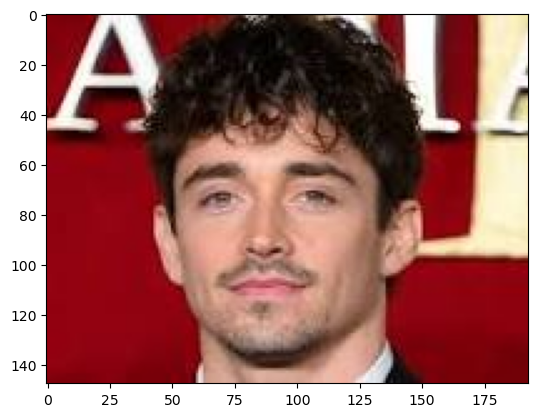

In [37]:
predict(r"C:\Users\HP\Desktop\download.jpg")